# Mall Customer Segmentation with K-Means and PCA

## 1. Goal

The goal of this notebook is to segment mall customers into different groups using unsupervised learning.

Unlike supervised learning, there is no target label. Instead, the model tries to discover natural patterns in the customer data.

In this notebook, I will:

- Load and explore a real customer segmentation dataset from Kaggle
- Select useful features for clustering
- Scale the data
- Use the elbow method and silhouette score to choose a suitable number of clusters
- Train a K-Means clustering model
- Visualise the customer segments
- Use PCA to reduce higher-dimensional data into 2D
- Interpret the customer groups from a business perspective

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub 

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

project_root = Path.cwd().parents[0]
sys.path.append(str(project_root))

from src.preprocessing import basic_info, check_missing_values
from src.evaluation import print_clustering_results

dataset_path = kagglehub.dataset_download(
    "vjchoudhary7/customer-segmentation-tutorial-in-python"
)

dataset_path = Path(dataset_path)

print("Dataset downloaded to:")
print(dataset_path)

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


Dataset downloaded to:
C:\Users\ADMIN\.cache\kagglehub\datasets\vjchoudhary7\customer-segmentation-tutorial-in-python\versions\1


## 2. Dataset

This notebook uses the Mall Customer Segmentation dataset from Kaggle.

The dataset contains basic customer information such as:

- CustomerID
- Gender
- Age
- Annual Income
- Spending Score

The goal is to group customers into meaningful segments based on their behaviour and demographics.

Because the dataset does not contain a target label, this is an unsupervised learning problem.

In [3]:
csv_files = list(dataset_path.glob("*.csv"))
df = pd.read_csv(csv_files[0])

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
basic_info(df)

Shape: (200, 5)

Columns:
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Data types:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [5]:
check_missing_values(df)

,missing_count,missing_percent
CustomerID,0,0.0
Gender,0,0.0
Age,0,0.0
Annual Income (k$),0,0.0
Spending Score (1-100),0,0.0


## 3. Quick EDA

Before applying clustering, I will explore the main customer features:

- Age
- Annual Income
- Spending Score

This helps me understand the data distribution and whether there are visible customer patterns.

### Annual Income Distribution

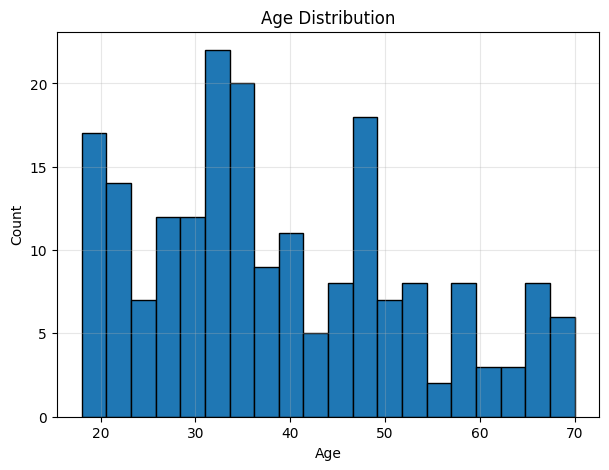

In [6]:
plt.figure(figsize=(7, 5))
plt.hist(df["Age"], bins=20, edgecolor="black")

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.show()

### Spending Score Distribution

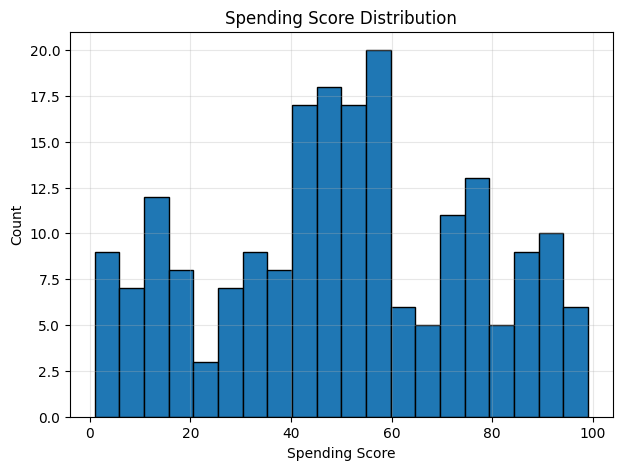

In [7]:
plt.figure(figsize=(7, 5))
plt.hist(df["Spending Score (1-100)"], bins=20, edgecolor="black")

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.show()

### Gender Count

In [8]:
df["Gender"].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

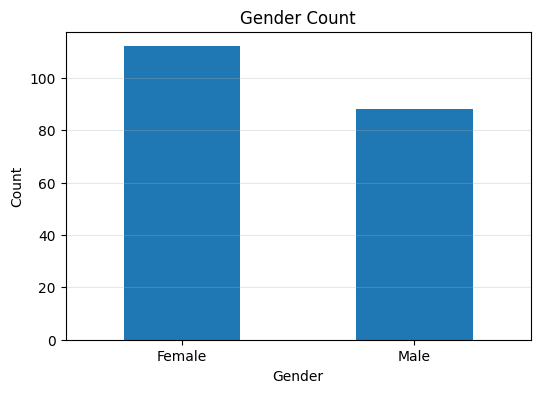

In [9]:
plt.figure(figsize=(6, 4))
df["Gender"].value_counts().plot(kind="bar")

plt.title("Gender Count")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

### Income vs Spending Score

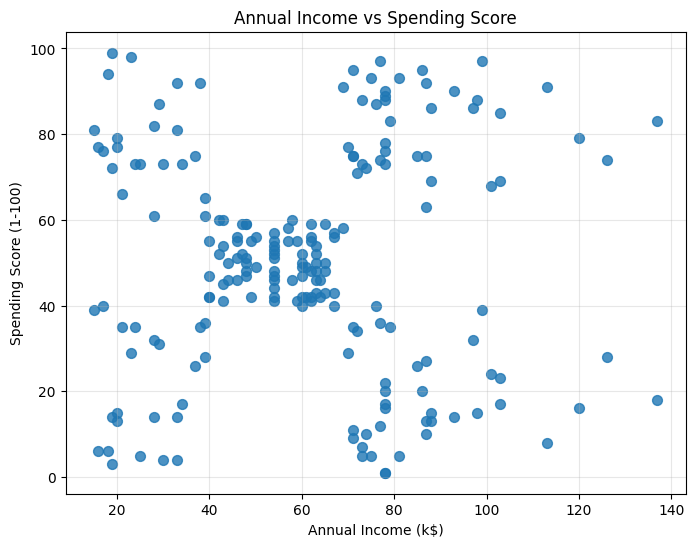

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    s=50,
    alpha=0.8
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.grid(alpha=0.3)
plt.show()

## 4. Preprocessing

For the first clustering model, I will use only:

- Annual Income
- Spending Score

This keeps the clustering problem easy to visualise in 2D.

Age can be added later to see whether the segmentation changes.

In [11]:
features_2d = ["Annual Income (k$)", "Spending Score (1-100)"]

X_2d = df[features_2d]

X_2d.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


K-Means is a distance-based algorithm.

Because it calculates distances between data points and cluster centers, feature scaling is important. Without scaling, a feature with a larger numeric range can dominate the clustering result.

In [12]:
scaler_2d = StandardScaler()

X_2d_scaled = scaler_2d.fit_transform(X_2d)

X_2d_scaled[:5]

X_2d_scaled_df = pd.DataFrame(
    X_2d_scaled,
    columns=features_2d
)

X_2d_scaled_df.head()

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


## 5. Choosing the Number of Clusters

K-Means requires the number of clusters, `k`, to be chosen before training.

I will use two methods:

1. Elbow method
2. Silhouette score

The elbow method checks how the within-cluster sum of squares, also called inertia, changes as the number of clusters increases.

In [13]:
inertias_2d = []

k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_2d_scaled)
    inertias_2d.append(kmeans.inertia_)

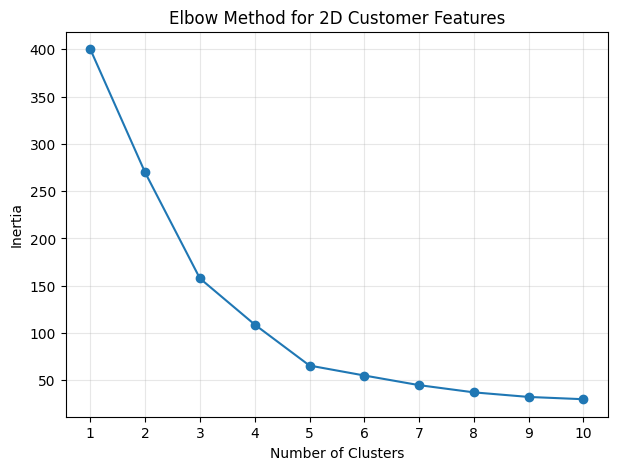

In [14]:
plt.figure(figsize=(7, 5))
plt.plot(k_values, inertias_2d, marker="o")

plt.title("Elbow Method for 2D Customer Features")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.show()

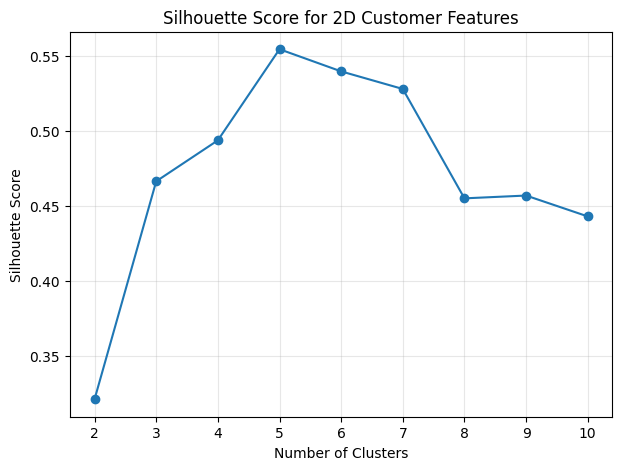

In [15]:
silhouette_scores_2d = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_2d_scaled)
    score = silhouette_score(X_2d_scaled, labels)
    silhouette_scores_2d.append(score)

plt.figure(figsize=(7, 5))
plt.plot(k_values, silhouette_scores_2d, marker="o")

plt.title("Silhouette Score for 2D Customer Features")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.show()

## 6. Model Training

Based on the elbow method, silhouette score, and visual inspection, I will use `k = 5` for the main 2D customer segmentation model.

In [16]:
final_k_2d = 5

kmeans_2d = KMeans(
    n_clusters=final_k_2d,
    random_state=42,
    n_init=10
)

cluster_labels_2d = kmeans_2d.fit_predict(X_2d_scaled)

df_clustered_2d = df.copy()
df_clustered_2d["Cluster_2D"] = cluster_labels_2d

df_clustered_2d.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster_2D
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [17]:
silhouette_2d = silhouette_score(X_2d_scaled, cluster_labels_2d)

print(f"2D K-Means Silhouette Score: {silhouette_2d:.4f}")

2D K-Means Silhouette Score: 0.5547


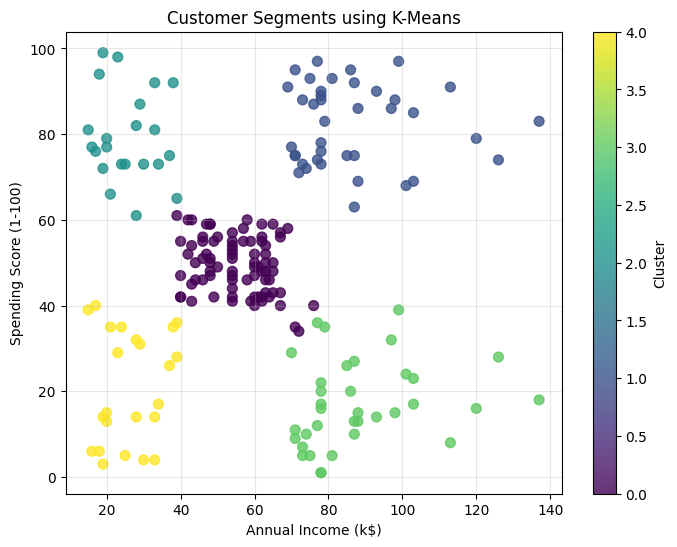

In [18]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    df_clustered_2d["Annual Income (k$)"],
    df_clustered_2d["Spending Score (1-100)"],
    c=df_clustered_2d["Cluster_2D"],
    s=50,
    alpha=0.8
)

plt.title("Customer Segments using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.colorbar(scatter, label="Cluster")
plt.grid(alpha=0.3)
plt.show()

In [19]:
centers_2d_scaled = kmeans_2d.cluster_centers_

centers_2d_original = scaler_2d.inverse_transform(centers_2d_scaled)

centers_2d_df = pd.DataFrame(
    centers_2d_original,
    columns=features_2d
)

centers_2d_df["Cluster_2D"] = range(final_k_2d)

centers_2d_df

,Annual Income (k$),Spending Score (1-100),Cluster_2D
0,55.296296,49.518519,0
1,86.538462,82.128205,1
2,25.727273,79.363636,2
3,88.200000,17.114286,3
4,26.304348,20.913043,4


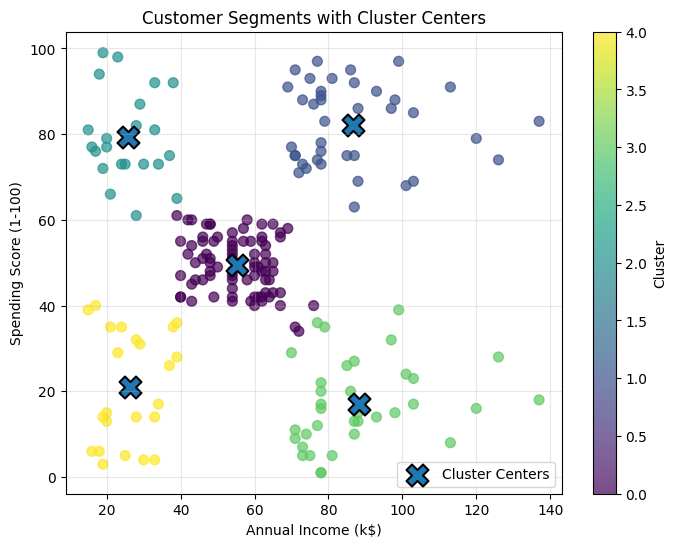

In [20]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    df_clustered_2d["Annual Income (k$)"],
    df_clustered_2d["Spending Score (1-100)"],
    c=df_clustered_2d["Cluster_2D"],
    s=50,
    alpha=0.7
)

plt.scatter(
    centers_2d_df["Annual Income (k$)"],
    centers_2d_df["Spending Score (1-100)"],
    s=250,
    marker="X",
    edgecolor="black",
    linewidth=1.5,
    label="Cluster Centers"
)

plt.title("Customer Segments with Cluster Centers")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.colorbar(scatter, label="Cluster")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. Cluster Profiling

The cluster labels from K-Means are just numbers. They do not have meaning by themselves.

To understand what each cluster represents, I will calculate the average age, income, spending score, and customer count for each cluster.

In [21]:
cluster_profile_2d = df_clustered_2d.groupby("Cluster_2D").agg({
    "Age": "mean",
    "Annual Income (k$)": "mean",
    "Spending Score (1-100)": "mean",
    "CustomerID": "count"
}).rename(columns={"CustomerID": "Customer Count"})

cluster_profile_2d.round(2)

,Age,Annual Income (k$),Spending Score (1-100),Customer Count
Cluster_2D,,,,
0,42.72,55.30,49.52,81
1,32.69,86.54,82.13,39
2,25.27,25.73,79.36,22
3,41.11,88.20,17.11,35
4,45.22,26.30,20.91,23


## 8. Clusters Identification

To make the clustering result easier to understand, I will assign business-friendly names based on the average age, income, spending score, and customer count in each cluster.

Based on the cluster profile:

- Cluster 0 has medium income and medium spending. This looks like the general customer group.
- Cluster 1 has high income and high spending. This is likely the most valuable customer group.
- Cluster 2 has low income but high spending. This group may contain younger customers who spend actively despite lower income.
- Cluster 3 has high income but low spending. These customers have spending potential but are currently not highly engaged.
- Cluster 4 has low income and low spending. This group is less active from a spending perspective.

In [22]:
cluster_profile_2d.round(2)
segment_names_2d = {
    0: "Standard Customers",
    1: "High Income High Spenders",
    2: "Low Income High Spenders",
    3: "High Income Low Spenders",
    4: "Low Income Low Spenders"
}

df_clustered_2d["Segment_2D"] = df_clustered_2d["Cluster_2D"].map(segment_names_2d)

df_clustered_2d.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster_2D,Segment_2D
0,1,Male,19,15,39,4,Low Income Low Spenders
1,2,Male,21,15,81,2,Low Income High Spenders
2,3,Female,20,16,6,4,Low Income Low Spenders
3,4,Female,23,16,77,2,Low Income High Spenders
4,5,Female,31,17,40,4,Low Income Low Spenders


In [23]:
segment_profile_2d = df_clustered_2d.groupby("Segment_2D").agg({
    "Age": "mean",
    "Annual Income (k$)": "mean",
    "Spending Score (1-100)": "mean",
    "CustomerID": "count"
}).rename(columns={"CustomerID": "Customer Count"})

segment_profile_2d.round(2)

,Age,Annual Income (k$),Spending Score (1-100),Customer Count
Segment_2D,,,,
High Income High Spenders,32.69,86.54,82.13,39
High Income Low Spenders,41.11,88.20,17.11,35
Low Income High Spenders,25.27,25.73,79.36,22
Low Income Low Spenders,45.22,26.30,20.91,23
Standard Customers,42.72,55.30,49.52,81


After renaming the clusters, the segment profile becomes easier to interpret.

The largest group is the standard customer segment, with average income and average spending. The high income high spender group is smaller, but likely more valuable from a business perspective because they combine strong income with high spending behaviour.

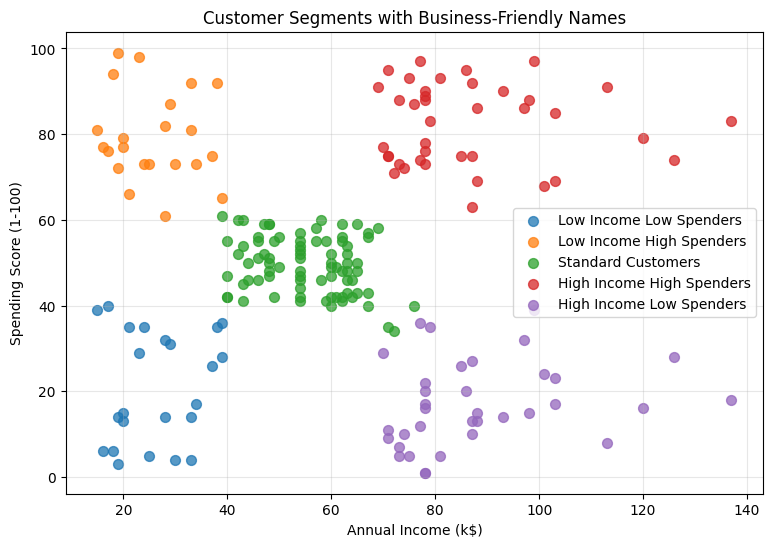

In [24]:
plt.figure(figsize=(9, 6))

for segment in df_clustered_2d["Segment_2D"].unique():
    segment_data = df_clustered_2d[df_clustered_2d["Segment_2D"] == segment]
    
    plt.scatter(
        segment_data["Annual Income (k$)"],
        segment_data["Spending Score (1-100)"],
        s=50,
        alpha=0.75,
        label=segment
    )

plt.title("Customer Segments with Business-Friendly Names")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 10. Adding Age to the Clustering

The first model only used annual income and spending score.

Now I will add age as a third feature. This gives the model more information, but it also makes the result harder to visualise directly because the data becomes 3-dimensional.

To handle this, I will use PCA later to project the 3-feature clustering result into 2D.

In [26]:
features_3d = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

X_3d = df[features_3d]

X_3d.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [27]:
scaler_3d = StandardScaler()

X_3d_scaled = scaler_3d.fit_transform(X_3d)

X_3d_scaled[:5]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

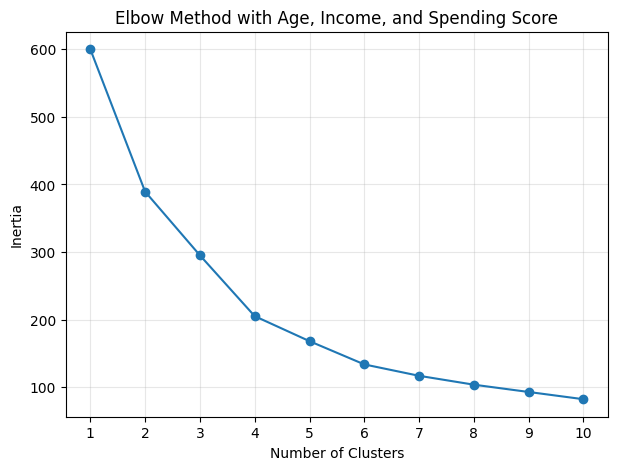

In [29]:
inertias_3d = []

k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_3d_scaled)
    inertias_3d.append(kmeans.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(k_values, inertias_3d, marker="o")

plt.title("Elbow Method with Age, Income, and Spending Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.show()

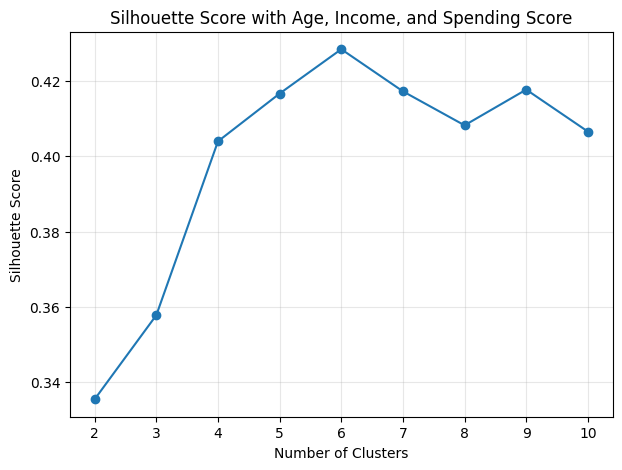

In [31]:
silhouette_scores_3d = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_3d_scaled)
    score = silhouette_score(X_3d_scaled, labels)
    silhouette_scores_3d.append(score)

plt.figure(figsize=(7, 5))
plt.plot(k_values, silhouette_scores_3d, marker="o")

plt.title("Silhouette Score with Age, Income, and Spending Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.show()

In [33]:
final_k_3d = 5

kmeans_3d = KMeans(
    n_clusters=final_k_3d,
    random_state=42,
    n_init=10
)

cluster_labels_3d = kmeans_3d.fit_predict(X_3d_scaled)

df_clustered_3d = df.copy()
df_clustered_3d["Cluster_3D"] = cluster_labels_3d

df_clustered_3d.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster_3D
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


In [35]:
silhouette_3d = silhouette_score(X_3d_scaled, cluster_labels_3d)

print(f"3D K-Means Silhouette Score: {silhouette_3d:.4f}")

3D K-Means Silhouette Score: 0.4166


In [36]:
cluster_profile_3d = df_clustered_3d.groupby("Cluster_3D").agg({
    "Age": "mean",
    "Annual Income (k$)": "mean",
    "Spending Score (1-100)": "mean",
    "CustomerID": "count"
}).rename(columns={"CustomerID": "Customer Count"})

cluster_profile_3d.round(2)

,Age,Annual Income (k$),Spending Score (1-100),Customer Count
Cluster_3D,,,,
0,46.25,26.75,18.35,20
1,25.19,41.09,62.24,54
2,32.88,86.10,81.53,40
3,39.87,86.10,19.36,39
4,55.64,54.38,48.85,47


## 11. PCA Visualisation

The 3D clustering model uses age, income, and spending score.

To visualise this result in 2D, I will use PCA.

PCA creates new features called principal components. These components capture as much variation in the data as possible.

In [37]:
pca = PCA(n_components=2)

X_3d_pca = pca.fit_transform(X_3d_scaled)

pca_df = pd.DataFrame(
    X_3d_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster_3D"] = cluster_labels_3d

pca_df.head()

,PC1,PC2,Cluster_3D
0,-0.615720,-1.763481,1
1,-1.665793,-1.820747,1
2,0.337862,-1.674799,0
3,-1.456573,-1.772430,1
4,-0.038465,-1.662740,1


In [38]:
explained_variance = pca.explained_variance_ratio_

print(f"PC1 explained variance: {explained_variance[0]:.2%}")
print(f"PC2 explained variance: {explained_variance[1]:.2%}")
print(f"Total explained variance: {explained_variance.sum():.2%}")

PC1 explained variance: 44.27%
PC2 explained variance: 33.31%
Total explained variance: 77.57%


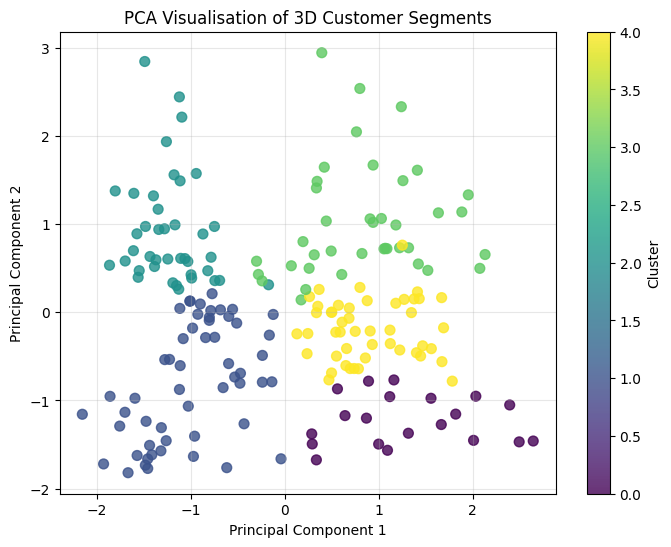

In [39]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster_3D"],
    s=50,
    alpha=0.8
)

plt.title("PCA Visualisation of 3D Customer Segments")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="Cluster")
plt.grid(alpha=0.3)
plt.show()